<a href="https://colab.research.google.com/github/Nehasatheesh04/Income_pred_ML/blob/main/income_prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas matplotlib seaborn scikit-learn numpy


In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/income.csv')

In [ ]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df.education.value_counts()

,count
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


In [ ]:
df.workclass.value_counts()

,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
?,2799
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


In [ ]:
df.occupation.value_counts()

,count
occupation,
Prof-specialty,6172
Craft-repair,6112
Exec-managerial,6086
Adm-clerical,5611
Sales,5504
Other-service,4923
Machine-op-inspct,3022
?,2809
Transport-moving,2355


In [ ]:
df.gender.value_counts()

,count
gender,
Male,32650
Female,16192


In [ ]:
pd.get_dummies(df.occupation)  #made it binry by creating a dummy

,?,Adm-clerical,Armed-Forces,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving
0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
48838,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
48839,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
48840,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
pd.get_dummies(df.occupation).add_prefix('occupation_') #added prefix to avoid conflict with other feature

,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
48838,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
48839,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
48840,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df = pd.concat([df.drop('occupation',axis=1),pd.get_dummies(df.occupation).add_prefix('occuption_')],axis=1) #dropped occupation feature and added abve dummy thing
df = pd.concat([df.drop('workclass',axis=1),pd.get_dummies(df.workclass).add_prefix('workclass_')],axis=1)
df=df.drop('education',axis=1)
df = pd.concat([df.drop('marital-status',axis=1),pd.get_dummies(df['marital-status']).add_prefix('marital-status_')],axis=1)
df = pd.concat([df.drop('relationship',axis=1),pd.get_dummies(df.relationship).add_prefix('relationship_')],axis=1)
df = pd.concat([df.drop('race',axis=1),pd.get_dummies(df.race).add_prefix('race_')],axis=1)
df = pd.concat([df.drop('native-country',axis=1),pd.get_dummies(df['native-country']).add_prefix('native-country_')],axis=1)



In [ ]:
df['gender'] = df['gender'].apply(lambda x:1  if x == 'Male' else 0)

df['income']=df['income'].apply(lambda x: 1 if x=='>50K' else 0)


In [ ]:
df


,age,fnlwgt,educational-num,gender,capital-gain,capital-loss,hours-per-week,income,occuption_?,occuption_Adm-clerical,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,1,0,0,40,0,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,1,0,0,50,0,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,1,0,0,40,1,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,1,7688,0,40,1,False,False,...,False,False,False,False,False,False,False,True,False,False
4,18,103497,10,0,0,0,30,0,True,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,257302,12,0,0,0,38,0,False,False,...,False,False,False,False,False,False,False,True,False,False
48838,40,154374,9,1,0,0,40,1,False,False,...,False,False,False,False,False,False,False,True,False,False
48839,58,151910,9,0,0,0,40,0,False,True,...,False,False,False,False,False,False,False,True,False,False
48840,22,201490,9,1,0,0,20,0,False,True,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
df.columns.values

array(['age', 'fnlwgt', 'educational-num', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'income', 'occuption_?',
       'occuption_Adm-clerical', 'occuption_Armed-Forces',
       'occuption_Craft-repair', 'occuption_Exec-managerial',
       'occuption_Farming-fishing', 'occuption_Handlers-cleaners',
       'occuption_Machine-op-inspct', 'occuption_Other-service',
       'occuption_Priv-house-serv', 'occuption_Prof-specialty',
       'occuption_Protective-serv', 'occuption_Sales',
       'occuption_Tech-support', 'occuption_Transport-moving',
       'workclass_?', 'workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay',
       'marital-status_Divorced', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent',
       'marital-status_Neve

<Axes: >

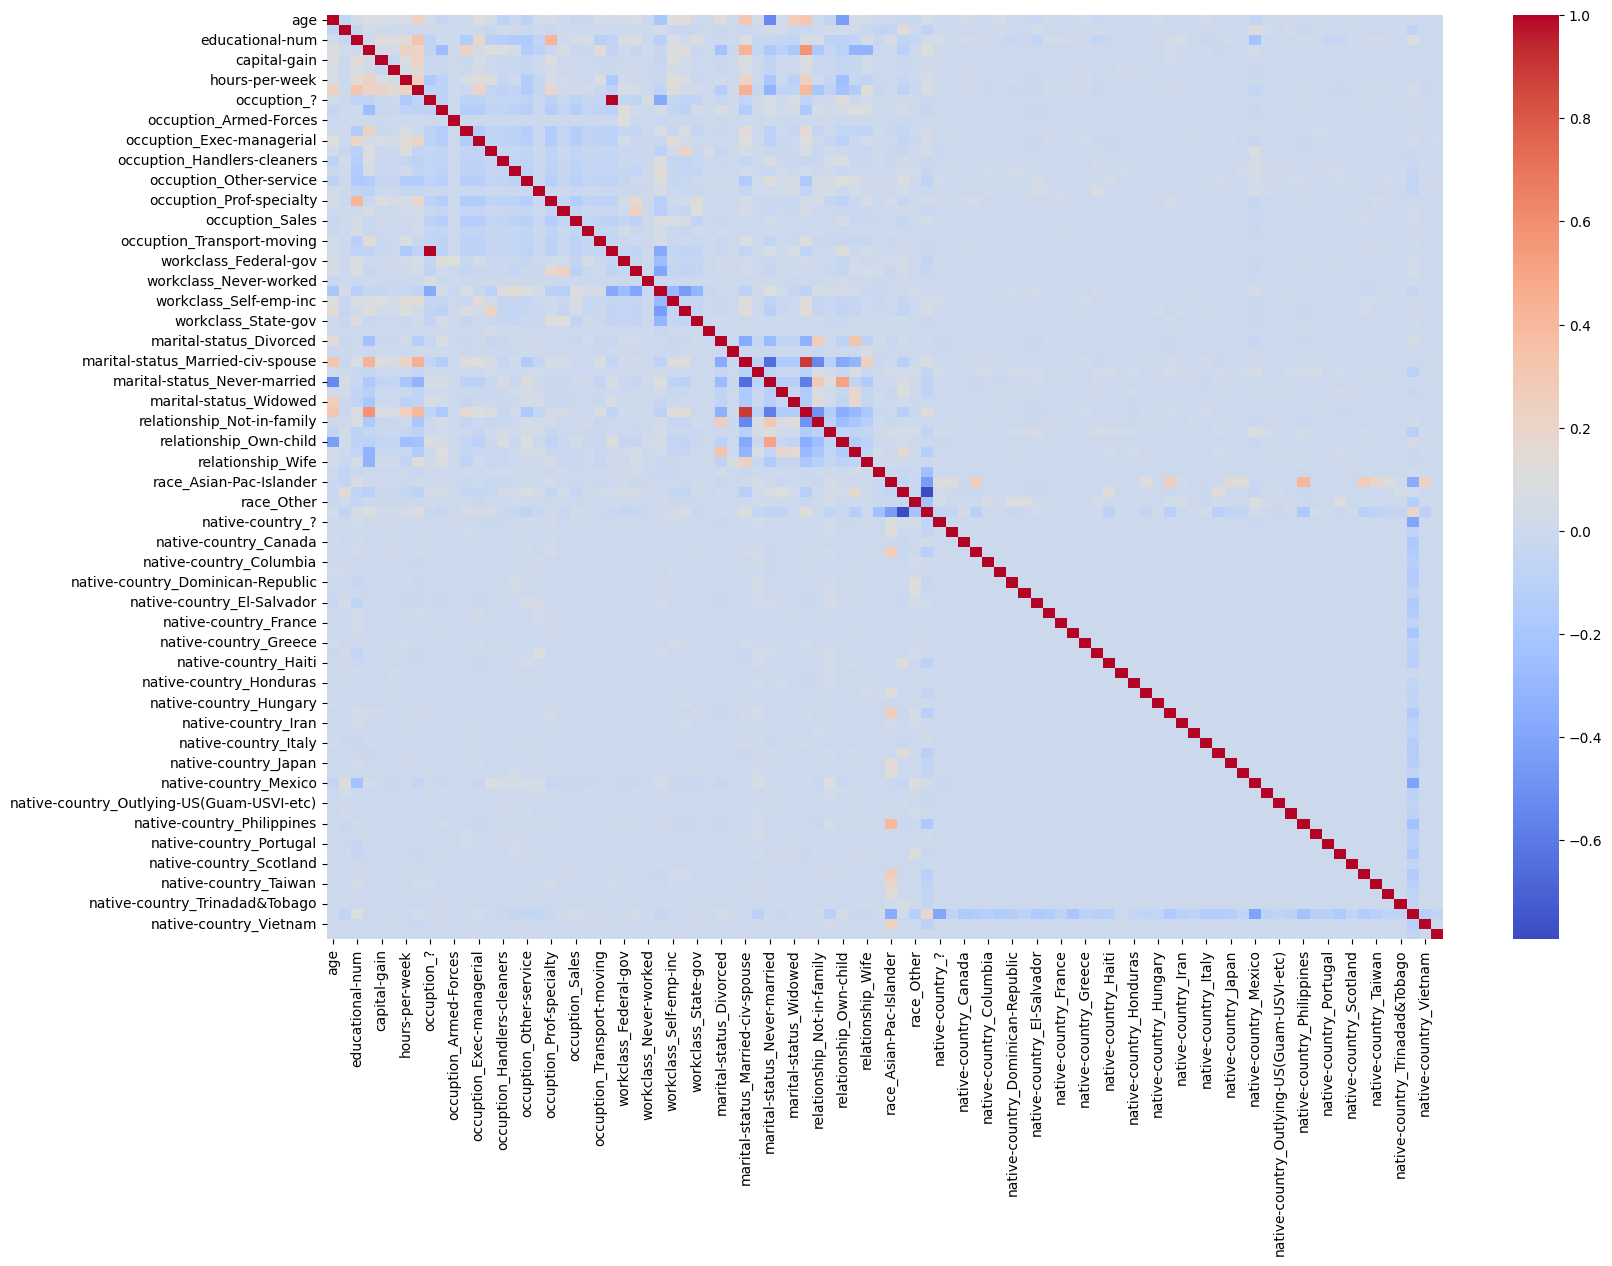

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))
sns.heatmap(df.corr(),annot=False,cmap='coolwarm')

In [ ]:
df.corr()

,age,fnlwgt,educational-num,gender,capital-gain,capital-loss,hours-per-week,income,occuption_?,occuption_Adm-clerical,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
age,1.000000,-0.076628,0.030940,0.088120,0.077229,0.056944,0.071558,0.230369,0.025683,-0.038116,...,0.007016,0.005474,0.012281,-0.001942,-0.011872,-0.001766,0.001056,0.011888,-0.012337,0.002905
fnlwgt,-0.076628,1.000000,-0.038761,0.027739,-0.003706,-0.004366,-0.013519,-0.006339,-0.005405,0.007480,...,-0.013577,0.008708,-0.006523,-0.010342,-0.001733,-0.001512,0.004153,-0.070645,-0.007479,0.004699
educational-num,0.030940,-0.038761,1.000000,0.009328,0.125146,0.080972,0.143689,0.332613,-0.080053,0.004142,...,-0.047816,-0.041776,0.000907,0.012984,0.045420,0.007283,-0.010201,0.104210,-0.007544,-0.005798
gender,0.088120,0.027739,0.009328,1.000000,0.047094,0.045480,0.228560,0.214628,-0.063844,-0.260349,...,0.009649,-0.009940,-0.002178,-0.005272,0.003041,-0.007117,-0.009342,-0.011167,-0.001545,0.005262
capital-gain,0.077229,-0.003706,0.125146,0.047094,1.000000,-0.031441,0.082157,0.223013,-0.019157,-0.029105,...,-0.004355,-0.006137,-0.002317,0.003906,0.004260,-0.002781,-0.003039,0.004191,-0.002673,-0.000474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
native-country_Thailand,-0.001766,-0.001512,0.007283,-0.007117,-0.002781,-0.002338,0.008558,-0.004219,-0.002575,-0.001157,...,-0.000919,-0.001525,-0.000514,-0.001204,-0.000905,1.000000,-0.000583,-0.073329,-0.001041,-0.000538
native-country_Trinadad&Tobago,0.001056,0.004153,-0.010201,-0.009342,-0.003039,0.004028,-0.002911,-0.009107,-0.002068,0.007917,...,-0.000872,-0.001446,-0.000488,-0.001143,-0.000859,-0.000583,1.000000,-0.069564,-0.000988,-0.000510
native-country_United-States,0.011888,-0.070645,0.104210,-0.011167,0.004191,0.009449,0.004390,0.032551,0.005546,0.022126,...,-0.109626,-0.181890,-0.061346,-0.143695,-0.107976,-0.073329,-0.069564,1.000000,-0.124226,-0.064202
native-country_Vietnam,-0.012337,-0.007479,-0.007544,-0.001545,-0.002673,-0.000118,-0.008289,-0.015542,-0.004082,0.010905,...,-0.001557,-0.002583,-0.000871,-0.002040,-0.001533,-0.001041,-0.000988,-0.124226,1.000000,-0.000912


In [ ]:
correlation=df.corr()['income'].abs()
sorted_correlations=correlation.sort_values()
num_cols_to_drop=int(0.8*len(df.columns))
cols_to_drop=sorted_correlations.iloc[:num_cols_to_drop].index
df_dropped=df.drop(cols_to_drop,axis=1)

In [ ]:
df_dropped

,age,educational-num,gender,capital-gain,capital-loss,hours-per-week,income,occuption_Exec-managerial,occuption_Other-service,occuption_Prof-specialty,workclass_Self-emp-inc,marital-status_Divorced,marital-status_Married-civ-spouse,marital-status_Never-married,relationship_Husband,relationship_Not-in-family,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,25,7,1,0,0,40,0,False,False,False,False,False,False,True,False,False,True,False,False
1,38,9,1,0,0,50,0,False,False,False,False,False,True,False,True,False,False,False,False
2,28,12,1,0,0,40,1,False,False,False,False,False,True,False,True,False,False,False,False
3,44,10,1,7688,0,40,1,False,False,False,False,False,True,False,True,False,False,False,False
4,18,10,0,0,0,30,0,False,False,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,12,0,0,0,38,0,False,False,False,False,False,True,False,False,False,False,False,True
48838,40,9,1,0,0,40,1,False,False,False,False,False,True,False,True,False,False,False,False
48839,58,9,0,0,0,40,0,False,False,False,False,False,False,False,False,False,False,True,False
48840,22,9,1,0,0,20,0,False,False,False,False,False,False,True,False,False,True,False,False


<Axes: >

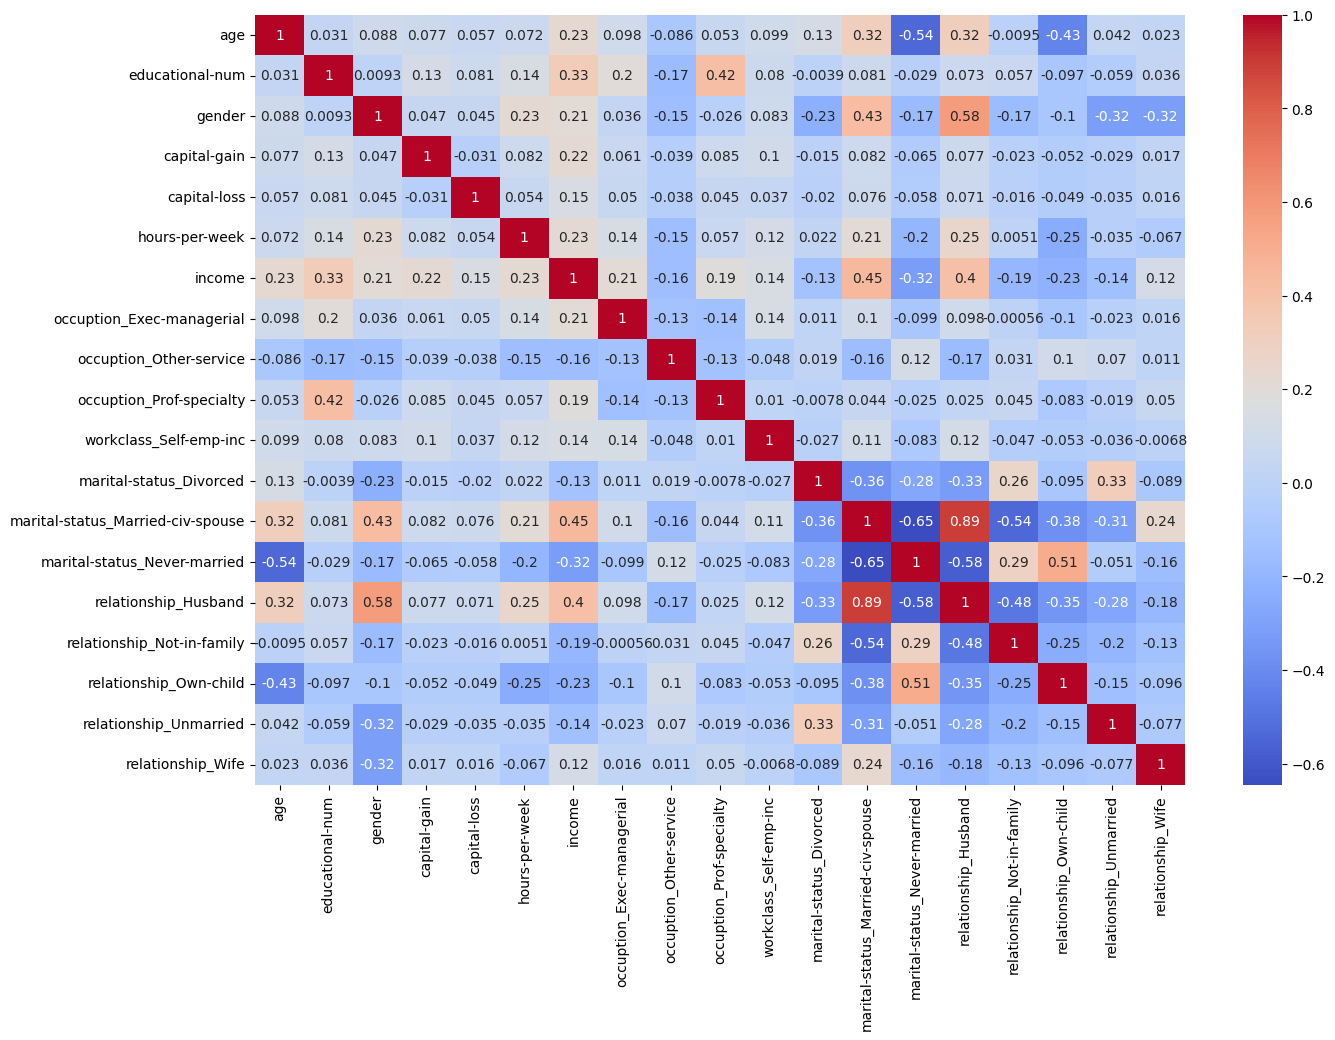

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df_dropped.corr(),annot=True,cmap='coolwarm')

In [ ]:
#random forest classifier is used bcs this dataset is a decision like thing mainly it have binary data
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df=df.drop('fnlwgt',axis=1)

train_df,test_df=train_test_split(df,test_size=0.2) #20% for testing

In [ ]:
train_df

,age,educational-num,gender,capital-gain,capital-loss,hours-per-week,income,occuption_?,occuption_Adm-clerical,occuption_Armed-Forces,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
32874,61,9,1,0,1887,40,1,False,False,False,...,False,False,False,False,False,False,False,True,False,False
46026,52,9,0,0,0,45,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
17996,39,10,0,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
35084,33,12,0,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
22510,36,9,0,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24734,35,9,1,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
36039,27,9,1,0,0,30,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
19012,62,15,1,0,0,30,1,False,False,False,...,False,False,False,False,False,False,False,True,False,False
48420,47,15,1,15024,0,40,1,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
test_df

,age,educational-num,gender,capital-gain,capital-loss,hours-per-week,income,occuption_?,occuption_Adm-clerical,occuption_Armed-Forces,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
36101,20,10,1,0,0,40,0,True,False,False,...,False,False,False,False,False,False,False,True,False,False
39236,56,9,1,0,0,90,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
23866,19,9,0,0,0,25,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
16486,18,7,0,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
42371,17,8,1,0,0,15,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36730,32,9,0,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
925,24,9,1,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
29817,17,6,1,0,0,35,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1455,32,10,0,0,0,38,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
train_x=train_df.drop('income',axis=1) #input features
train_y=train_df['income']    #target

test_x=test_df.drop('income',axis=1)
test_y=test_df['income']

In [ ]:
forest = RandomForestClassifier()

forest.fit(train_x,train_y)

RandomForestClassifier()

In [ ]:
forest.score(test_x,test_y)

0.8482956290306071

In [ ]:
forest.feature_importances_

array([2.25196426e-01, 1.30686353e-01, 1.52352278e-02, 1.10362156e-01,
       3.68858141e-02, 1.14322947e-01, 1.87284062e-03, 5.10507748e-03,
       8.42160913e-05, 5.82845326e-03, 2.21147048e-02, 4.68770879e-03,
       3.11080927e-03, 3.71122156e-03, 8.13191559e-03, 1.59843501e-04,
       1.85131064e-02, 2.67879970e-03, 5.99000035e-03, 4.74580013e-03,
       4.08189403e-03, 1.76749218e-03, 4.76356315e-03, 5.56894086e-03,
       2.19538770e-07, 8.98550476e-03, 5.91294288e-03, 7.98086980e-03,
       4.37422211e-03, 1.01327486e-04, 9.14659775e-03, 3.00787590e-04,
       6.58161517e-02, 9.21821132e-04, 2.29687423e-02, 2.15514887e-03,
       1.87887119e-03, 4.60723165e-02, 1.37835435e-02, 2.23439682e-03,
       1.08810535e-02, 5.65485785e-03, 9.68479150e-03, 1.54662257e-03,
       3.28812721e-03, 4.85666330e-03, 9.90778945e-04, 6.30611071e-03,
       2.86752193e-03, 3.89684823e-04, 1.34110069e-03, 5.66889027e-04,
       3.40124029e-04, 8.16507575e-04, 2.44843973e-04, 1.46107773e-04,
      

In [ ]:
forest.feature_names_in_

array(['age', 'educational-num', 'gender', 'capital-gain', 'capital-loss',
       'hours-per-week', 'occuption_?', 'occuption_Adm-clerical',
       'occuption_Armed-Forces', 'occuption_Craft-repair',
       'occuption_Exec-managerial', 'occuption_Farming-fishing',
       'occuption_Handlers-cleaners', 'occuption_Machine-op-inspct',
       'occuption_Other-service', 'occuption_Priv-house-serv',
       'occuption_Prof-specialty', 'occuption_Protective-serv',
       'occuption_Sales', 'occuption_Tech-support',
       'occuption_Transport-moving', 'workclass_?',
       'workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay',
       'marital-status_Divorced', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent',
       'marital-status_Never-married', 'marital

In [ ]:
dict(zip(forest.feature_names_in_,forest.feature_importances_))

{'age': 0.22519642564817377,
 'educational-num': 0.130686352795284,
 'gender': 0.015235227799918687,
 'capital-gain': 0.11036215647039228,
 'capital-loss': 0.03688581413735136,
 'hours-per-week': 0.1143229473440255,
 'occuption_?': 0.0018728406173646956,
 'occuption_Adm-clerical': 0.005105077483816182,
 'occuption_Armed-Forces': 8.421609128013544e-05,
 'occuption_Craft-repair': 0.005828453258441228,
 'occuption_Exec-managerial': 0.022114704771674258,
 'occuption_Farming-fishing': 0.00468770879040768,
 'occuption_Handlers-cleaners': 0.0031108092666399106,
 'occuption_Machine-op-inspct': 0.00371122156081736,
 'occuption_Other-service': 0.008131915593495558,
 'occuption_Priv-house-serv': 0.00015984350144121766,
 'occuption_Prof-specialty': 0.018513106358332226,
 'occuption_Protective-serv': 0.002678799699642076,
 'occuption_Sales': 0.0059900003455157355,
 'occuption_Tech-support': 0.004745800125621816,
 'occuption_Transport-moving': 0.00408189402759205,
 'workclass_?': 0.00176749217975862

In [ ]:
importances=dict(zip(forest.feature_names_in_,forest.feature_importances_))
importances={k:v for k,v in sorted(importances.items(),key=lambda x:x[1],reverse=True)}

In [ ]:
importances

{'age': 0.22519642564817377,
 'educational-num': 0.130686352795284,
 'hours-per-week': 0.1143229473440255,
 'capital-gain': 0.11036215647039228,
 'marital-status_Married-civ-spouse': 0.06581615167099021,
 'relationship_Husband': 0.046072316484031414,
 'capital-loss': 0.03688581413735136,
 'marital-status_Never-married': 0.02296874234037307,
 'occuption_Exec-managerial': 0.022114704771674258,
 'occuption_Prof-specialty': 0.018513106358332226,
 'gender': 0.015235227799918687,
 'relationship_Not-in-family': 0.013783543487404242,
 'relationship_Own-child': 0.010881053502846991,
 'relationship_Wife': 0.00968479149522957,
 'marital-status_Divorced': 0.009146597745021294,
 'workclass_Private': 0.008985504757498774,
 'occuption_Other-service': 0.008131915593495558,
 'workclass_Self-emp-not-inc': 0.007980869795118585,
 'native-country_United-States': 0.0063168214253161905,
 'race_White': 0.006306110712946908,
 'occuption_Sales': 0.0059900003455157355,
 'workclass_Self-emp-inc': 0.00591294288338

In [ ]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV

#parameters
param_grid={
    'n_estimators':[50,100,250],
    'max_depth':[5,10,30,None],
    'min_samples_split':[2,4],
    'max_features':['sqrt','log2']
}

grid_search=GridSearchCV(estimator=RandomForestClassifier(),
                         param_grid=param_grid,verbose=10)

In [ ]:
grid_search.fit(train_x,train_y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5; 1/48] START max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50
[CV 1/5; 1/48] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50;, score=0.841 total time=   0.6s
[CV 2/5; 1/48] START max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50
[CV 2/5; 1/48] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50;, score=0.837 total time=   0.6s
[CV 3/5; 1/48] START max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50
[CV 3/5; 1/48] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50;, score=0.843 total time=   0.6s
[CV 4/5; 1/48] START max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50
[CV 4/5; 1/48] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50;, score=0.842 total time=   0.6s
[CV 5/5; 1/48] START max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=50
[CV 

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, 30, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 4],
                         'n_estimators': [50, 100, 250]},
             verbose=10)

In [ ]:
grid_search.best_estimator_

RandomForestClassifier(max_depth=30, max_features='log2', min_samples_split=4,
                       n_estimators=250)

In [ ]:
 forest=grid_search.best_estimator_

In [ ]:
forest.score(test_x,test_y)

0.8596581021598936

In [ ]:
importances=dict(zip(forest.feature_names_in_,forest.feature_importances_))
importances={k:v for k,v in sorted(importances.items(),key=lambda x:x[1],reverse=True)}

In [ ]:
importances

{'age': 0.14274001094405817,
 'educational-num': 0.1364110886004718,
 'capital-gain': 0.13174066013036298,
 'hours-per-week': 0.08958711114025215,
 'marital-status_Married-civ-spouse': 0.0813549044911918,
 'relationship_Husband': 0.0644679461158564,
 'capital-loss': 0.04230528791363654,
 'marital-status_Never-married': 0.03501209582040713,
 'occuption_Exec-managerial': 0.02586506441843695,
 'occuption_Prof-specialty': 0.02252674054589506,
 'relationship_Not-in-family': 0.018838672401565473,
 'gender': 0.017052747017119726,
 'relationship_Own-child': 0.014102217458318356,
 'relationship_Wife': 0.012302258651195906,
 'occuption_Other-service': 0.010461519336391398,
 'marital-status_Divorced': 0.009562961210010705,
 'relationship_Unmarried': 0.009229110395807158,
 'workclass_Self-emp-not-inc': 0.00817984474837256,
 'workclass_Private': 0.008007375175258643,
 'workclass_Self-emp-inc': 0.00735594687292321,
 'occuption_Craft-repair': 0.0057580144343070214,
 'native-country_United-States': 0.